In [1]:
# IMPORTS
from memo import memo, domain
from math import exp
import jax
import numpy as np
import jax.numpy as jnp
from jax.scipy.stats import beta as jax_beta
from scipy.stats import beta as sp_beta_dist
import matplotlib.pyplot as plt
import seaborn as sns

# GLOBALS
INFO, ACTION = 0, 1
CAN, IMP, NULL = 0, 1, 2
goals = [INFO, ACTION]
U = [CAN, IMP, NULL]

# COSTS
c_can, c_imp = .1, .7 # utterance costs for speaker
c_effort = .1 # physical cost for actioner
w_cost = 0.0 # willingness cost for actioner
c_act = c_effort + w_cost

prior_ga = .5 # uniform prior over goals for now

mu_vals = np.linspace(0.001, .999, 50)   # grid over ability
theta_vals = np.linspace(0.01, 0.99, 20) #threshold values
kappa = 20   # tightness over beta_agg dist (ie a+b)
alpha = 5    # softmax param

In [2]:
## A0 -- literal actioner
f1, f2, f3 = .05, .99, .9 # eg proximity, motor ability, hands free, etc
f_agg = float(np.prod([f1, f2, f3])) # product of preconditions


# P(f_agg > theta)
def p_yes(mu, t):
    mu_c = jnp.clip(mu, .01, .99)
    return 1.0 - jax_beta.cdf(t, mu_c * kappa, (1 - mu_c) * kappa)

def A0(u, t, mu):
    return p_yes(mu, t) if u != NULL else 0.0

print(f"f_agg={f_agg:.3f}")
print(f"A0(can, t=.5, mu=.5) = {float(A0(CAN, theta_vals[1], mu_vals[25])):.3f}")
print(f"A0(imp, t=.5, mu=.5) = {float(A0(IMP, theta_vals[1], mu_vals[25])):.3f}")
print(f"A0(null, t=.5, mu=.5) = {float(A0(NULL, theta_vals[1], mu_vals[25])):.3f}")

f_agg=0.045
A0(can, t=.5, mu=.5) = 1.000
A0(imp, t=.5, mu=.5) = 1.000
A0(null, t=.5, mu=.5) = 0.000


In [3]:
## S1
u_label = {CAN: 'can', IMP: 'imp', NULL: 'null'}
goal_label = {INFO: 'info', ACTION: 'action'}


@jax.jit
def eu_s1(u, g, mu, t):
    p = p_yes(mu, t)
    v = 4 * p * (1-p) # info value function (cost implicature)
    eu_can = jnp.where(g == 1, 0., v) - c_can
    eu_imp = jnp.where(g ==1, p, v) - c_imp
    return jnp.where(u == 2, 0., jnp.where(u ==  0, eu_can, eu_imp))

# P(u | g, mu, t)
@memo
def S1[_u: U, _g: goals, _mu: mu_vals, _t: theta_vals](alpha):
    speaker: knows(_g, _mu, _t)
    speaker: chooses(u in U, wpp=exp(alpha * eu_s1(u, _g, _mu, _t))) # softmax over utterances
    return Pr[speaker.u == _u]

s1_out = S1(alpha)
ti_mid = int(len(theta_vals) // 2)
for gi, g in enumerate(goals):
    probs = {u_label[u]: round(float(s1_out[ui, gi, 25, ti_mid]), 3) for ui, u in enumerate(U)}
    print(f"S1(g={goal_label[g]}, mu=.5, t={theta_vals[ti_mid]:.2f}) = {probs}")


S1(g=info, mu=.5, t=0.53) = {'can': 0.942, 'imp': 0.047, 'null': 0.011}
S1(g=action, mu=.5, t=0.53) = {'can': 0.321, 'imp': 0.149, 'null': 0.53}


In [4]:
## A1

@jax.jit
def goal_prior(g, prior_ga):
    return jnp.where(g == 1, prior_ga, 1 - prior_ga) # 1 = action, 0 = info


@memo
def A1[_g: goals](prior_ga, alpha):
    a1: knows(_g)
    a1: thinks[
        spk: given(g in goals, wpp=goal_prior(g, prior_ga)),
        spk: given(mu in mu_vals, wpp = 1),
        spk: given(t in theta_vals, wpp = 1),
        spk: chooses(u in U, wpp = S1[u, g, mu, t](alpha))
    ]
    a1: observes_that[spk.u == 0]
    return a1[Pr[spk.g == _g]]

def a1_act(prior_ga):
    p_ga = float(A1(prior_ga = prior_ga, alpha=alpha)[ACTION])
    eu_do = 1 - c_act
    eu_ans = 1 - p_ga
    probs = jnp.exp(alpha * jnp.array([eu_do, eu_ans]))
    return float(probs[0] / probs.sum())

print(f"A1 action selection:")
for p in [.3, .5, .85]:
    p_ga = float(A1(prior_ga = p, alpha=alpha)[ACTION])
    print(f" prior={p}: P(g_action|u) = {p_ga:.3f}, P(do|u) = {a1_act(p):.3f}")


A1 action selection:
 prior=0.3: P(g_action|u) = 0.171, P(do|u) = 0.587
 prior=0.5: P(g_action|u) = 0.324, P(do|u) = 0.754
 prior=0.85: P(g_action|u) = 0.731, P(do|u) = 0.959


In [5]:
## S2

# basically the same thing here, except that S2 now reasons that A1 could act
@jax.jit
def eu_s2(u, g, mu, t, p_a1_do):
    p = p_yes(mu, t)
    v = 4 * p * (1-p)
    eu_can = jnp.where(g == 1, p_a1_do, v) - c_can
    eu_imp = jnp.where(g ==1, p, v) - c_imp
    return jnp.where(u == 2, 0, jnp.where(u ==  0, eu_can, eu_imp))

@memo
def S2[_u: U, _g: goals, _mu: mu_vals, _t: theta_vals](p_a1_do, alpha):
    speaker: knows(_g, _mu, _t)
    speaker: chooses(u in U, wpp=exp(alpha * eu_s2(u, _g, _mu, _t, p_a1_do)))
    return Pr[speaker.u == _u]

s2_out = S2(p_a1_do = a1_act(.5), alpha=alpha)
for gi, g in enumerate(goals):
    probs = {u_label[u]: round(float(s2_out[ui, gi, 25, ti_mid]), 3) for ui, u in enumerate(U)}
    print(f"S2(g={goal_label[g]}, mu=.5, t={theta_vals[ti_mid]:.2f}) = {probs}")

S2(g=info, mu=.5, t=0.53) = {'can': 0.942, 'imp': 0.047, 'null': 0.011}
S2(g=action, mu=.5, t=0.53) = {'can': 0.954, 'imp': 0.01, 'null': 0.036}


In [6]:
## A2

@memo
def A2[_g: goals](prior_ga, p_a1_do, alpha):
    a2: knows(_g)
    a2: thinks[
        spk: given(g in goals, wpp=goal_prior(g, prior_ga)),
        spk: given(mu in mu_vals, wpp = 1),
        spk: given(t in theta_vals, wpp = 1),
        spk: chooses(u in U, wpp = S2[u, g, mu, t](p_a1_do, alpha))
    ]
    a2: observes_that[spk.u == 0]
    return a2[Pr[spk.g == _g]]

def a2_act(prior_ga):
    p_ga = float(A2(prior_ga = prior_ga, p_a1_do = a1_act(prior_ga), alpha=alpha)[ACTION])
    eu_do = 1 - c_act
    eu_ans = 1 - p_ga
    probs = jnp.exp(alpha * jnp.array([eu_do, eu_ans]))
    return float(probs[0] / probs.sum())

print(f"A2: priors and action selection:")
for p in [.3, .5, .85]:
    p_ga = float(A2(prior_ga = p, p_a1_do = a1_act(p), alpha=alpha)[ACTION])
    print(f" prior={p}: P(g_action|u) = {p_ga:.3f}, P(do|u) = {a2_act(p):.3f}")

A2: priors and action selection:
 prior=0.3: P(g_action|u) = 0.405, P(do|u) = 0.821
 prior=0.5: P(g_action|u) = 0.638, P(do|u) = 0.937
 prior=0.85: P(g_action|u) = 0.914, P(do|u) = 0.983


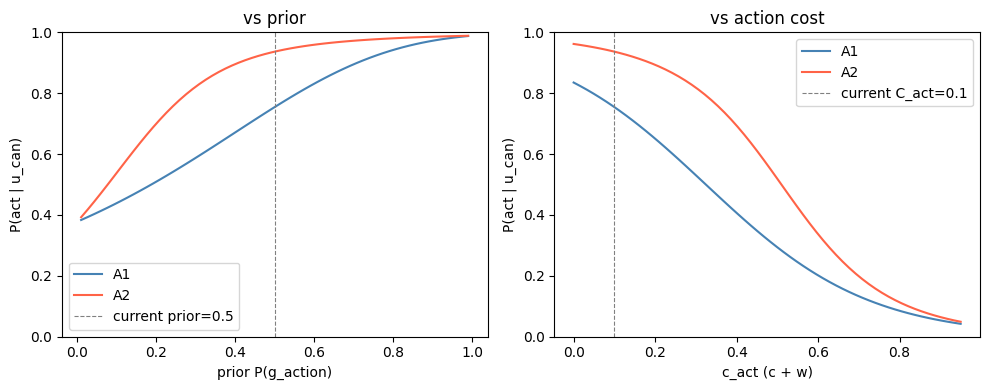

In [7]:
## plots: A1 vs A2

def act_at(prior_ga, c):
    """P(do X) for A1 and A2 at given prior and action cost c"""
    eu_do = 1 - c - w_cost

    p_ga1   = float(A1(prior_ga=prior_ga, alpha=alpha)[ACTION])            
    eu_ans1 = 1 - p_ga1
    p1      = jnp.exp(alpha * jnp.array([eu_do, eu_ans1]))
    p_a1    = float(p1[0] / p1.sum())                                         

    p_ga2   = float(A2(prior_ga=prior_ga, p_a1_do=p_a1, alpha=alpha)[ACTION]) 
    eu_ans2 = 1 - p_ga2
    p2      = jnp.exp(alpha * jnp.array([eu_do, eu_ans2]))
    p_a2    = float(p2[0] / p2.sum())                                          

    return p_a1, p_a2

priors = np.linspace(0.01, 0.99, 60)
costs  = np.linspace(0.0,  0.95, 60)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))


ax = axes[0]
a1v, a2v = zip(*[act_at(p, c_act) for p in priors])
ax.plot(priors, a1v, label='A1', color='steelblue')
ax.plot(priors, a2v, label='A2', color='tomato')
ax.axvline(prior_ga, color='gray', linestyle='--', linewidth=.8, label=f'current prior={prior_ga}')
ax.set_xlabel('prior P(g_action)')
ax.set_ylabel('P(act | u_can)')
ax.set_title(f'vs prior')
ax.legend(); ax.set_ylim(0, 1)


ax = axes[1]
a1v, a2v = zip(*[act_at(prior_ga, c) for c in costs])
ax.plot(costs, a1v, label='A1', color='steelblue')
ax.plot(costs, a2v, label='A2', color='tomato')
ax.axvline(c_act, color='gray', linestyle='--', linewidth=.8, label=f'current C_act={c_act}')
ax.set_xlabel('c_act (c + w)')
ax.set_ylabel('P(act | u_can)')
ax.set_title(f'vs action cost')
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

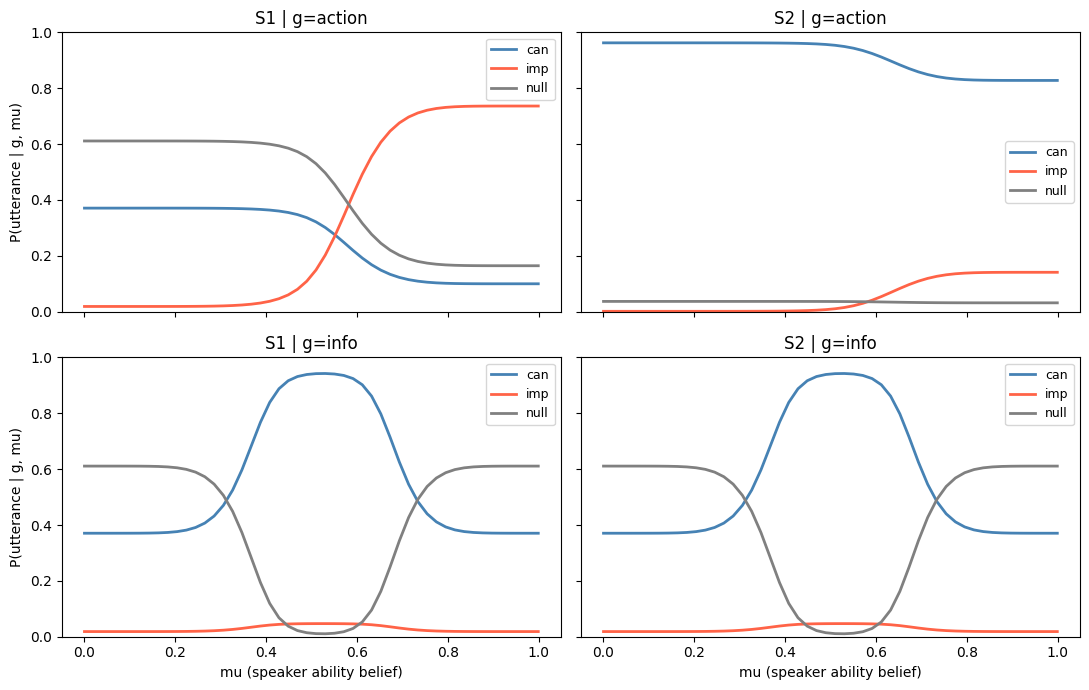

In [8]:
## plots: S1 vs S2
s2_out_curr = S2(p_a1_do=a1_act(prior_ga), alpha=alpha)

u_colors = {CAN: 'steelblue', IMP: 'tomato', NULL: 'gray'}
u_labels = {CAN: 'can', IMP: 'imp', NULL: 'null'}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)

for ri, (gi, glabel) in enumerate([(ACTION, 'g=action'), (INFO, 'g=info')]):
    for ci, (out, mlabel) in enumerate([(s1_out, 'S1'), (s2_out_curr, 'S2')]):
        ax = axes[ri, ci]
        for ui in U:
            ax.plot(mu_vals, out[ui, gi, :, ti_mid],
                    color=u_colors[ui], label=u_labels[ui], linewidth=2)
        ax.set_title(f'{mlabel} | {glabel}')
        ax.set_ylim(0, 1)
        if ri == 1: ax.set_xlabel('mu (speaker ability belief)')
        if ci == 0: ax.set_ylabel('P(utterance | g, mu)')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()